In [ ]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import pandas as pd
import numpy as np

#import copula functions
from pr_copula.main_copula_regression_conditional import fit_copula_cregression,predict_copula_cregression,predictive_resample_cregression,check_convergence_pr_cregression

from causal_mp import mp_causal_density
from causal_mp_iv import mp_density_iv

## Motivating Example

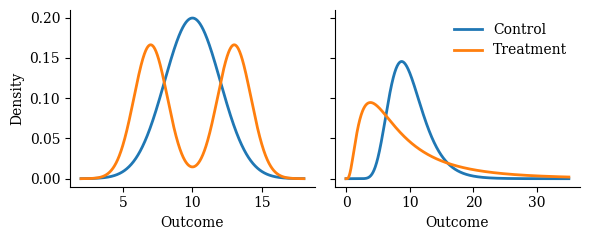

In [4]:
from scipy.stats import norm, lognorm

# --- Parameters ---
mu = 10          # The common mean
sigma_0 = 2.0    # SD for control
x = np.linspace(mu - 8, mu + 8, 1000) # Slightly wider range for the tail

# 1. Polarization Parameters
delta = 3
sigma_sub = 1.2

# 2. Lottery Parameters
s = 0.7  # Shape parameter (skewness)
# For a Lognormal with scale=1, mean is exp(s^2 / 2). 
# To shift the mean to 'mu', we set loc = mu - exp(s^2 / 2)
loc_shift = mu - np.exp(s**2 / 2)

# --- Calculate PDFs ---

# Shared Control PDF
pdf_y0 = norm.pdf(x, mu, sigma_0)

# Left: Polarization Treatment (Mixture)
pdf_y1_pol = 0.5 * norm.pdf(x, mu - delta, sigma_sub) + 0.5 * norm.pdf(x, mu + delta, sigma_sub)

# Right: Lottery Treatment (Shifted Log-Normal)
target_mean = 10
x_b = np.linspace(0, 35, 1000) # Longer tail for lottery

# Control: Lower skewness
s0 = 0.3
mu0 = np.log(target_mean) - (s0**2 / 2)
pdf_y0_b = lognorm.pdf(x_b, s0, scale=np.exp(mu0))
# Treatment: Higher skewness
s1 = 0.8
mu1 = np.log(target_mean) - (s1**2 / 2)
pdf_y1_b = lognorm.pdf(x_b, s1, scale=np.exp(mu1))


# --- Plotting ---
plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        10,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.linewidth":   0.8,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 2.5), sharey=True)

# Panel A: Polarization
ax1.plot(x, pdf_y0, label='Control', lw=2)
ax1.plot(x, pdf_y1_pol, label='Treatment', lw=2)
ax1.set_xlabel("Outcome")
ax1.set_ylabel("Density")


# Panel B: Lottery
ax2.plot(x_b, pdf_y0_b, label='Control', lw=2)
ax2.plot(x_b, pdf_y1_b, label='Treatment', lw=2)
ax2.set_xlabel("Outcome")
ax2.legend(frameon=False)

plt.tight_layout()
plt.savefig("Figures/Motivating_Example.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Unconfounded with one covariate

In [5]:
from scipy.stats import t as student_t

T_DF = 3  # degrees of freedom for the heavy-tailed errors

def generate_data(n):
    W = np.random.uniform(0, 1, n)
    # 1. Create a mixture selector (coin flip) for Y(1)
    mode_selector = np.random.binomial(1, 3/4, n)
    
    # 2. Define Y(0) and Y(1)
    y0 = student_t.rvs(T_DF, loc=W / 2, scale=1, size=n)
    y1_mode_a = student_t.rvs(T_DF, loc=W, scale=0.5, size=n)
    y1_mode_b = student_t.rvs(T_DF, loc=2 + W, scale=0.5, size=n)
    y1 = np.where(mode_selector == 1, y1_mode_a, y1_mode_b)
    
    # 3. Treatment assignment
    probs = np.where(W > 0.5, 0.6, 0.4)
    X = (np.random.uniform(0, 1, n) < probs).astype(int)
    
    # 4. Observed Outcome
    Y_obs = np.where(X == 1, y1, y0)
    
    return Y_obs, X, W

def true_y0_density(y_vals, n_w=200):
    w_grid = np.linspace(0, 1, n_w)
    
    # Y(0) ~ t_3(W/2, 1)
    mu = w_grid / 2
    dens = student_t.pdf(y_vals[:, None], T_DF, loc=mu[None, :], scale=1)
    
    # Average over W
    return np.mean(dens, axis=1)

def true_y1_density(y_vals, n_w=200):
    w_grid = np.linspace(0, 1, n_w)
    
    # Mode A density
    mu_a = w_grid
    dens_a = student_t.pdf(y_vals[:, None], T_DF, loc=mu_a[None, :], scale=0.5)
    
    # Mode B density
    mu_b = 2 + w_grid
    dens_b = student_t.pdf(y_vals[:, None], T_DF, loc=mu_b[None, :], scale=0.5)
    
    # Total density is the average of both modes across all W
    return np.mean((3/4) * dens_a + (1/4) * dens_b, axis=1)


def generate_data_scenario2(n):
    W = np.random.uniform(0, 1, n)
    # 1. Create a mixture selector (coin flip) for Y(1) and Y(0)
    mode_selector = np.random.binomial(1, 3/4, n)
    
    # 2. Define Y(0) and Y(1) as shifted bimodal distributions
    # Y(0): mixture of t_3(W-1, 0.5) and t_3(1+W, 0.5)  [shifted down by 1 from Y(1)]
    y0_mode_a = student_t.rvs(T_DF, loc=W - 1, scale=0.5, size=n)
    y0_mode_b = student_t.rvs(T_DF, loc=1 + W, scale=0.5, size=n)
    y0 = np.where(mode_selector == 1, y0_mode_a, y0_mode_b)
    
    # Y(1): mixture of t_3(W, 0.5) and t_3(2+W, 0.5)
    y1_mode_a = student_t.rvs(T_DF, loc=W, scale=0.5, size=n)
    y1_mode_b = student_t.rvs(T_DF, loc=2 + W, scale=0.5, size=n)
    y1 = np.where(mode_selector == 1, y1_mode_a, y1_mode_b)
    
    # 3. Treatment assignment
    probs = np.where(W > 0.5, 0.6, 0.4)
    X = (np.random.uniform(0, 1, n) < probs).astype(int)
    
    # 4. Observed Outcome
    Y_obs = np.where(X == 1, y1, y0)
    
    return Y_obs, X, W

def true_y0_density_scenario2(y_vals, n_w=200):
    w_grid = np.linspace(0, 1, n_w)
    
    # Mode A density: t_3(W-1, 0.5)
    mu_a = w_grid - 1
    dens_a = student_t.pdf(y_vals[:, None], T_DF, loc=mu_a[None, :], scale=0.5)
    
    # Mode B density: t_3(1+W, 0.5)
    mu_b = 1 + w_grid
    dens_b = student_t.pdf(y_vals[:, None], T_DF, loc=mu_b[None, :], scale=0.5)
    
    # Total density is the average of both modes across all W
    return np.mean((3/4) * dens_a + (1/4) * dens_b, axis=1)


In [ ]:
# load data
np.random.seed(42)
n = 200
y, x, w = generate_data(n)

# define parameters
y_grid = np.linspace(y.min() - 0.5, y.max() + 0.5, 50)
T_fwd, B_post = 1000, 100

# True density functions
true_y0 = true_y0_density(y_grid)
true_y1 = true_y1_density(y_grid)

# fit martingale posteriors and compute density estimates for S-Learner
res_s = mp_causal_density(y, x, w, y_grid, B_post, T_fwd)
res_s_c, res_s_t = res_s['x_0'], res_s['x_1']

# fit martingale posteriors and compute density estimates for T-Learner
res_t = mp_causal_density(y, x, w, y_grid, B_post, T_fwd, learner="t")
res_t_c, res_t_t = res_t['x_0'], res_t['x_1']


In [ ]:
# Scenario 2: Bimodal Y(0) and Y(1) shifted
np.random.seed(42)
n = 200
y2, x2, w2 = generate_data_scenario2(n)

y_grid2 = np.linspace(y2.min() - 0.5, y2.max() + 0.5, 50)

true_y02 = true_y0_density_scenario2(y_grid2)
true_y12 = true_y1_density(y_grid2)

# fit for S-Learner
res_s2 = mp_causal_density(y2, x2, w2, y_grid2, B_post, T_fwd)
res_s2_c, res_s2_t = res_s2['x_0'], res_s2['x_1']

# fit for T-Learner
res_t2 = mp_causal_density(y2, x2, w2, y_grid2, B_post, T_fwd, learner="t")
res_t2_c, res_t2_t = res_t2['x_0'], res_t2['x_1']


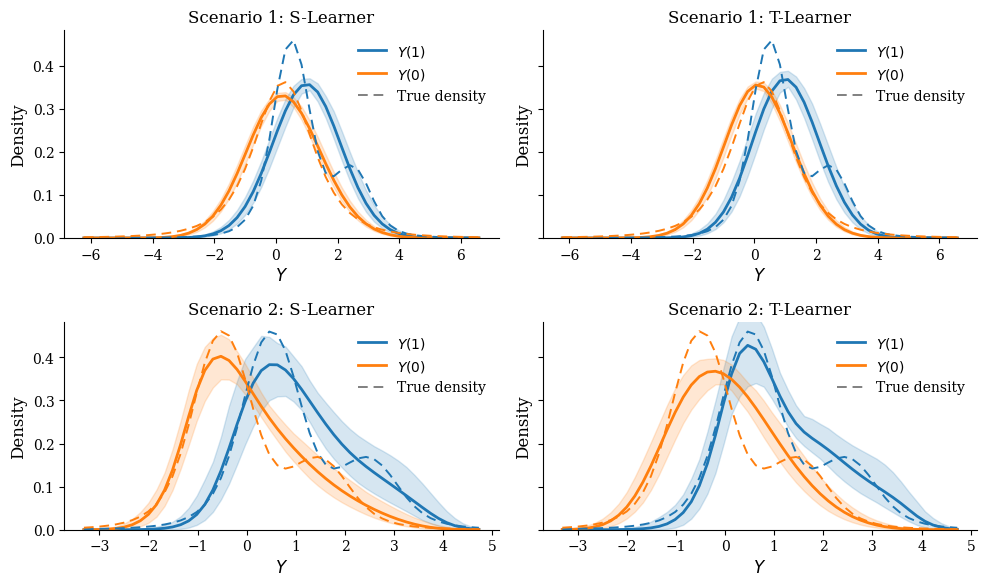

In [12]:
from matplotlib.lines import Line2D

# ── style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        11,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.linewidth":   0.8,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
})

RED  = "#1f77b4"  # swap to your preferred colours if needed
TEAL = "#ff7f0e"
ALPHA = 0.18
DASH  = (0, (5, 3))

legend_handles = [
    Line2D([0], [0], color=RED,  linewidth=2, label=r"$Y(1)$"),
    Line2D([0], [0], color=TEAL, linewidth=2, label=r"$Y(0)$"),
    Line2D([0], [0], color="grey", linewidth=1.4, linestyle=DASH, label="True density"),
]

def plot_panel(ax, grid, res_t, res_c, true_t, true_c, title):
    ax.fill_between(grid, res_t['low'], res_t['high'], color=RED,  alpha=ALPHA)
    ax.fill_between(grid, res_c['low'], res_c['high'], color=TEAL, alpha=ALPHA)
    ax.plot(grid, res_t['mean'], color=RED,  linewidth=2)
    ax.plot(grid, res_c['mean'], color=TEAL, linewidth=2)
    ax.plot(grid, true_t, color=RED,  linewidth=1.4, linestyle=DASH)
    ax.plot(grid, true_c, color=TEAL, linewidth=1.4, linestyle=DASH)
    ax.set_xlabel(r"$Y$", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.set_title(title, fontsize=12, pad=6)
    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=10)
    ax.legend(handles=legend_handles, frameon=False, fontsize=10)

fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharey=True)

plot_panel(axs[0,0], y_grid,  res_s_t,  res_s_c,  true_y1,  true_y0,  "Scenario 1: S-Learner")
plot_panel(axs[0,1], y_grid,  res_t_t,  res_t_c,  true_y1,  true_y0,  "Scenario 1: T-Learner")
plot_panel(axs[1,0], y_grid2, res_s2_t, res_s2_c, true_y12, true_y02, "Scenario 2: S-Learner")
plot_panel(axs[1,1], y_grid2, res_t2_t, res_t2_c, true_y12, true_y02, "Scenario 2: T-Learner")

fig.tight_layout()
plt.savefig('Figures/Density_Sim.pdf', dpi=300, bbox_inches='tight')
plt.show()

## IV with continuous treatment

In [18]:
def generate_iv_dgp(
    n: int = 1000,
    seed: int = 42,
    beta: float = 2.0,
    pi: float = 0.5,
    alpha: float = 1.0,
) -> dict:
    
    rng = np.random.default_rng(seed)

    Z = rng.standard_normal(n)

    # Cholesky of [[1, 0.5], [0.5, 1]]
    cov = np.array([[1.0, 0.5], [0.5, 1.0]])
    L = np.linalg.cholesky(cov)
    raw = rng.standard_normal((n, 2))
    errors = raw @ L.T          # shape (n, 2); columns are e_x, e_y

    X = pi * Z + errors[:, 0]
    Y = alpha + beta * X + errors[:, 1]

    return Y, X, Z



In [ ]:
# define parameters and simulate data
alpha, beta = 1.0, 1.0
y, x, z = generate_iv_dgp(n = 500, alpha = alpha, beta = beta, seed = 11)
T_fwd, B_post = 1500, 200

x_val = 1

# standardise y
mean_y, sd_y = np.mean(y), np.std(y)
y_std = (y - mean_y) / sd_y

y_grid = np.linspace(-2.0, 5.0, 30)
y_grid_std = (y_grid - mean_y) / sd_y

# fit martingale posteriors and compute density estimates
res = mp_density_iv(y_std, x, z, x_val, y_grid_std, B_post, T_fwd)['x_0']

# fit observational model as comparison
res_obs = mp_causal_density(y_std, x, np.ones(len(y)), y_grid_std, B_post, T_fwd, x_vals=x_val)['x_0']


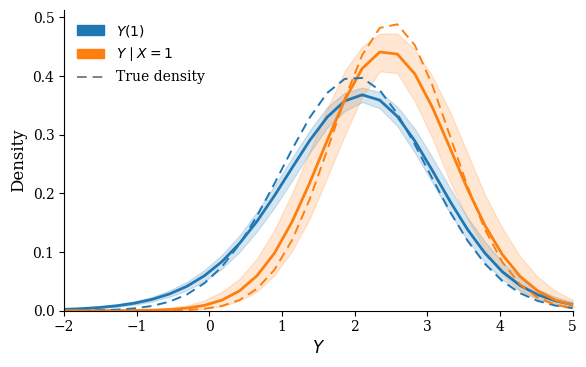

In [42]:
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D


# ── style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        11,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.linewidth":   0.8,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
})

BLUE   = "#1f77b4"
ORANGE = "#ff7f0e"
ALPHA  = 0.18

fig, ax = plt.subplots(figsize=(6, 3.8))


true_int = norm.pdf(y_grid, loc=alpha + beta * x_val,  scale=1)
true_obs = norm.pdf(y_grid, loc=alpha + (1/2 + beta) * x_val,  scale= 1 - 3/4 * 1/4)

# ── estimated densities + credible bands ───────────────────────────────────
ax.fill_between(y_grid, res['low'] / sd_y,  res['high'] / sd_y,  color=BLUE, alpha=ALPHA)
ax.fill_between(y_grid, res_obs['low'] / sd_y, res_obs['high'] / sd_y, color=ORANGE, alpha=ALPHA)

ax.plot(y_grid, res['mean'] / sd_y,  color=BLUE,   linewidth=2)
ax.plot(y_grid, res_obs['mean'] / sd_y,  color=ORANGE,   linewidth=2)

# ── true densities (dashed) ────────────────────────────────────────────────
ax.plot(y_grid, true_int,  color=BLUE,   linewidth=1.4, linestyle=(0, (5, 3)))
ax.plot(y_grid, true_obs,  color=ORANGE,   linewidth=1.4, linestyle=(0, (5, 3)))

# ── legend: estimated curves only + single "true" entry ───────────────────
legend_handles = [
    mpatches.Patch(color=BLUE,   label=r"$Y(1)$"),
    mpatches.Patch(color=ORANGE, label=r"$Y \mid X = 1$"),
    Line2D([0], [0], color="grey", linewidth=1.4,
           linestyle=(0, (5, 3)), label="True density"),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=10)

# ── axes labels & layout ───────────────────────────────────────────────────
ax.set_xlabel(r"$Y$",       fontsize=12)
ax.set_ylabel("Density",    fontsize=12)
ax.set_xlim(y_grid[0], y_grid[-1])
ax.set_ylim(bottom=0)
ax.tick_params(labelsize=10)

fig.tight_layout()
plt.savefig('Figures/IV_Simulation.pdf', dpi=300, bbox_inches='tight')
plt.show()
